## Introduction
- GPU: Tesla K80 GPU of about 12GB / Tesla T4 about 15GB
- Runtime is limited to 12 hours.
- https://colab.research.google.com
- https://colab.research.google.com/notebooks/welcome.ipynb

## Yolov4
- https://github.com/AlexeyAB/darknet

In [1]:
import tensorflow
print(tensorflow.__version__)

2.5.0


In [ ]:
!nvidia-smi

Wed Sep 16 23:44:15 2020       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 450.66       Driver Version: 418.67       CUDA Version: 10.1     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   50C    P8    11W /  70W |      0MiB / 15079MiB |      0%      Default |
|                               |                      |                 ERR! |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Cuda Version

In [ ]:
!/usr/local/cuda/bin/nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2019 NVIDIA Corporation
Built on Sun_Jul_28_19:07:16_PDT_2019
Cuda compilation tools, release 10.1, V10.1.243


## Install cuDNN 7.6.5 on linux for Cuda 10.1

### Download cuDNN from :
- https://developer.nvidia.com/rdp/form/cudnn-download-survey
- http://file.ppwwyyxx.com/nvidia/


In [ ]:
!tar -xzvf "gdrive/My Drive/Colab/darknetv4/cuDNN/cudnn-10.1-linux-x64-v7.6.5.32.tgz" -C /usr/local/
!chmod a+r /usr/local/cuda/include/cudnn.h
!cat /usr/local/cuda/include/cudnn.h | grep CUDNN_MAJOR -A 2

cuda/include/cudnn.h
cuda/NVIDIA_SLA_cuDNN_Support.txt
cuda/lib64/libcudnn.so
cuda/lib64/libcudnn.so.7
cuda/lib64/libcudnn.so.7.6.5
cuda/lib64/libcudnn_static.a
#define CUDNN_MAJOR 7
#define CUDNN_MINOR 6
#define CUDNN_PATCHLEVEL 5
--
#define CUDNN_VERSION (CUDNN_MAJOR * 1000 + CUDNN_MINOR * 100 + CUDNN_PATCHLEVEL)

#include "driver_types.h"


In [ ]:
%cd "/content/gdrive/My Drive/Colab/darknetv4/darknet/"

/content/gdrive/My Drive/Colab/darknetv4/darknet


In [ ]:
!ls

3rdparty		 DarknetConfig.cmake.in  obj
backup			 darknet.py		 predictions.jpg
bad.list		 darknet_video.py	 R2D2.avi
build			 data			 README.md
build.ps1		 image_yolov2.sh	 results
build.sh		 image_yolov3.sh	 robots_yolov4.mp4
cfg			 img			 scripts
chart.png		 include		 src
chart_yolov4-robots.png  json_mjpeg_streams.sh	 video_v2.sh
cmake			 LICENSE		 video_yolov3.sh
CMakeLists.txt		 Makefile		 weights
darknet			 net_cam_v3.sh


In [ ]:
!make
!chmod +x ./darknet

chmod +x *.sh


## Utility Functions

In [ ]:
from google.colab import files

def show_img(path):
  import cv2
  import matplotlib.pyplot as plt
  %matplotlib inline

  image = cv2.imread(path)
  height, width = image.shape[:2]
  resized_image = cv2.resize(image,(3*width, 3*height), interpolation = cv2.INTER_CUBIC)

  fig = plt.gcf()
  fig.set_size_inches(18, 10)
  plt.axis("off")
  #plt.rcParams['figure.figsize'] = [10, 5]
  plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
  plt.show()
  
  
def upload():
  files.upload() 
  
      
def download(path):
  files.download(path)

## Yolo on Images

In [ ]:
!./darknet detect cfg/yolov4.cfg weights/yolov4.weights data/person.jpg -i 0 -thresh 0.25

 CUDA-version: 10010 (10010), cuDNN: 7.6.5, GPU count: 1  
 OpenCV version: 3.2.0
 0 : compute_capability = 750, cudnn_half = 0, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.006 BF
   8 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   9 rout

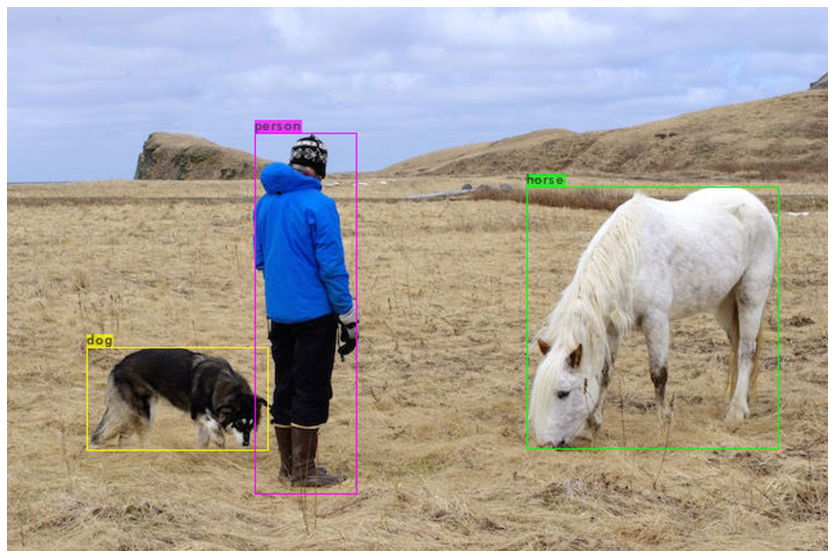

In [ ]:
show_img('predictions.jpg')

## Training custom dataset

In [ ]:
! ./darknet detector train data/robots-obj.data cfg/yolov4-robots.cfg weights/yolov4.conv.137 -dont_show
#!./darknet detector train data/robots-obj.data cfg/yolov4-robots.cfg ./backup/yolov4-robots_last.weights -dont_show

Streaming output truncated to the last 5000 lines.
v3 (iou loss, Normalizer: (iou: 0.07, cls: 1.00) Region 139 Avg (IOU: 0.000000, GIOU: 0.000000), Class: 0.000000, Obj: 0.000000, No Obj: 0.000001, .5R: 0.000000, .75R: 0.000000, count: 1, class_loss = 0.000000, iou_loss = 0.000000, total_loss = 0.000000 
v3 (iou loss, Normalizer: (iou: 0.07, cls: 1.00) Region 150 Avg (IOU: 0.000000, GIOU: 0.000000), Class: 0.000000, Obj: 0.000000, No Obj: 0.000004, .5R: 0.000000, .75R: 0.000000, count: 1, class_loss = 0.000003, iou_loss = 0.000000, total_loss = 0.000003 
v3 (iou loss, Normalizer: (iou: 0.07, cls: 1.00) Region 161 Avg (IOU: 0.958150, GIOU: 0.958013), Class: 0.999874, Obj: 0.987613, No Obj: 0.003732, .5R: 1.000000, .75R: 1.000000, count: 1, class_loss = 0.000156, iou_loss = 0.066390, total_loss = 0.066546 
 total_bbox = 2363666, rewritten_bbox = 0.131871 % 
v3 (iou loss, Normalizer: (iou: 0.07, cls: 1.00) Region 139 Avg (IOU: 0.000000, GIOU: 0.000000), Class: 0.000000, Obj: 0.000000, No 

## Testing the new trained model in a video:

In [ ]:
!./darknet detector demo data/robots-obj.data cfg/yolov4-robots.cfg ./backup/yolov4-robots_last.weights -dont_show R2D2.avi -i 0 -out_filename robots_yolov4.mp4

Streaming output truncated to the last 5000 lines.
FPS:33.7 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 36% 

FPS:33.9 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 44% 

FPS:33.3 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 44% 

FPS:33.4 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 41% 

FPS:33.4 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 44% 

FPS:33.6 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 47% 

FPS:33.6 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 37% 

FPS:33.6 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 33% 

FPS:33.7 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 32% 

FPS:33.8 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:

c3po: 34% 

FPS:33.8 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:


FPS:33.6 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:


FPS:33.6 	 AVG_FPS:33.5

 cvWriteFrame 
Objects:


FPS:33.6 	 AVG_FPS:33.4

 cvWriteFrame 
Objects:


FPS:33.5 	 AVG_FPS:33.4

 cvWriteFrame 
Objects:


FPS:33.5 	 AVG_FPS:33.4

 cvWriteFrame 
Objects:


FPS:33.3 	 AVG_FPS:33.4

In [ ]:
download('robots_yolov4.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Note:
After training to boost the performance, increase the network resolution in yolov4-robots.cfg to 608x608 or 832x832 — this makes it possible to detect small objects. 